# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [3]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


I0000 00:00:1789528425.154402    8310 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789528425.738385    8310 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789528427.987919    8310 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [4]:
# Esta parte está resuelta.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [5]:
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:** Flatten() convierte la imagen de 32x32 a un vector de 1024 valores (32*32=1024).



## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [6]:
# TODO 1 — Normalización
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())


0.0 1.0


In [7]:
# Validación TODO 1
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


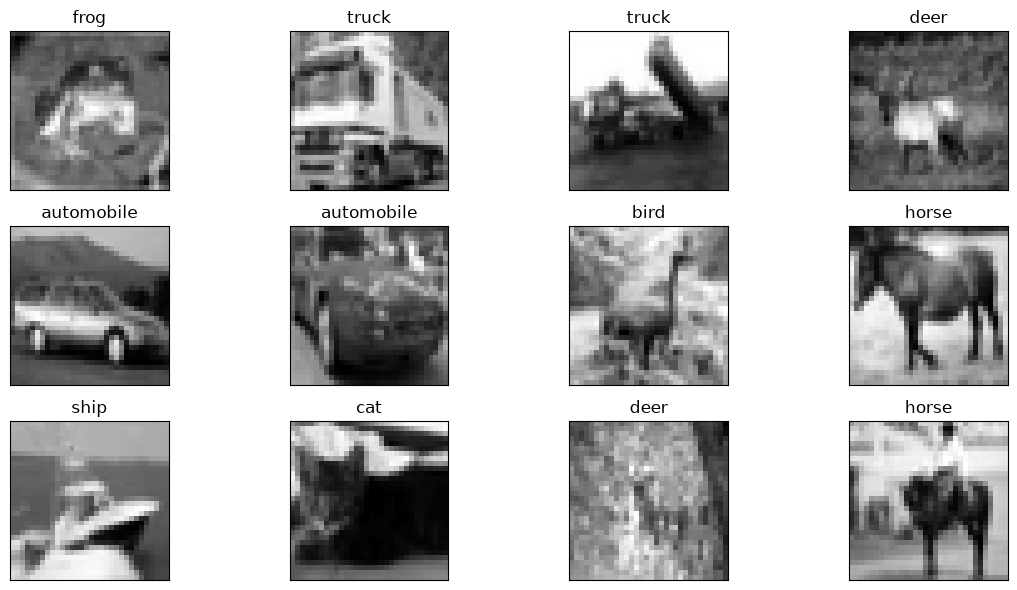

In [8]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [11]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10)
])

model.summary()


E0000 00:00:1789528545.277146    8310 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Validación TODO 2
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:** Para convertir los datos de entrada de una matriz (32x32) a un vector unidimensional (1024 valores) que pueda ser procesado por la capa Dense


**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:** Porque el dataset tiene 10 clases diferentes, y cada neurona de la última capa representa un logit para cada una de esas clases.


**4.** ¿Qué función cumple `ReLU`?

**Respuesta:** ReLU convierte los valores negativos en cero y mantiene los valores positivos. Su función es introducir no linealidad en la red neuronal.



---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [13]:
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:** Porque la salida de la red no es una probabilidad, son logits, y necesitamos que la función de pérdida interprete correctamente estos valores para calcular la pérdida de manera adecuada.



---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [14]:
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2519 - loss: 2.0627 - val_accuracy: 0.2951 - val_loss: 1.9707
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3129 - loss: 1.9233 - val_accuracy: 0.3170 - val_loss: 1.8954
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3400 - loss: 1.8646 - val_accuracy: 0.3352 - val_loss: 1.8579
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3523 - loss: 1.8291 - val_accuracy: 0.3502 - val_loss: 1.8192
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3629 - loss: 1.8001 - val_accuracy: 0.3565 - val_loss: 1.8055
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3708 - loss: 1.7789 - val_accuracy: 0.3572 - val_loss: 1.7956
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3767 - loss: 1.7614 - val_accuracy: 0.3652 - val_loss: 1.7850
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3821 - loss: 1.7466 - val_accuracy: 0.

### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:** Es un recorrido completo por todo el dataset de entrenamiento, donde la red neuronal ve cada ejemplo y actualiza sus pesos en función de la pérdida calculada.


**7.** ¿Qué representa `batch_size=64`?

**Respuesta:** El tamaño del batch nos dice cuántos ejemplos del dataset de entrenamiento se procesan antes de actualizar los pesos de la red.



## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


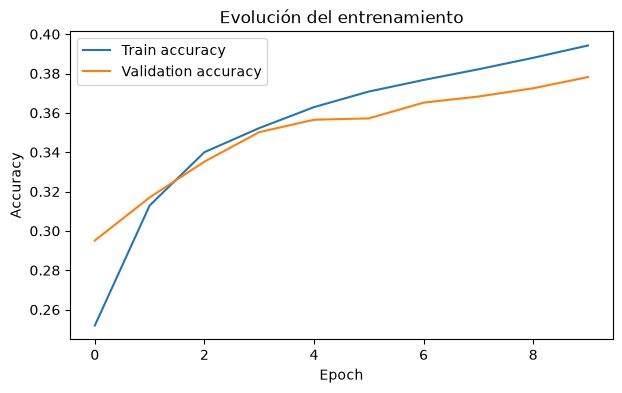

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:** Sí, se podría decir que hay overfitting. La curva de entrenamiento sigue mejorando mientras que la curva de validación se estabiliza o incluso empeora, lo que indica que el modelo está aprendiendo demasiado bien los datos de entrenamiento y no generaliza bien a los datos de prueba.



---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [16]:
# TODO 5 — Evaluación
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 1.7462
Test accuracy : 0.3782
Accuracy (%)  : 37.82%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:**



---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


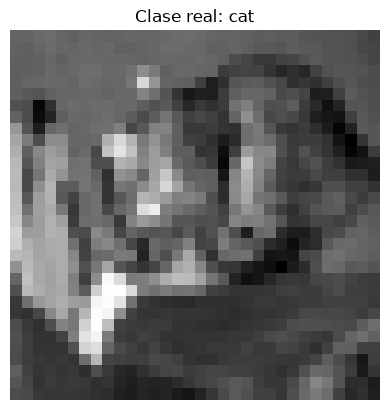

Logits:
[[ 0.35540277 -2.176513    1.1777558   0.24719992  1.1313361  -0.1366781
   0.32600605  0.5098528   0.36287218 -2.1238182 ]]


In [19]:
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

image_batch = np.expand_dims(image, axis=0)
logits = model(image_batch, training=False)

print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [20]:
# TODO 6 — Logits -> probabilidades
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])


Clase real     : cat
Clase predicha : bird


In [21]:
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.0974
automobile  : 0.0077
bird        : 0.2217 ← predicción
cat         : 0.0874
deer        : 0.2116
dog         : 0.0596
frog        : 0.0946
horse       : 0.1137
ship        : 0.0981
truck       : 0.0082

Suma: 0.99999994


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:** Porque Softmax convierte los logits en probabilidad, por tanto, la suma de todas las probabilidades debe ser igual a 1, lo que permite interpretar cada valor como la probabilidad de que la imagen pertenezca a cada clase.



---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


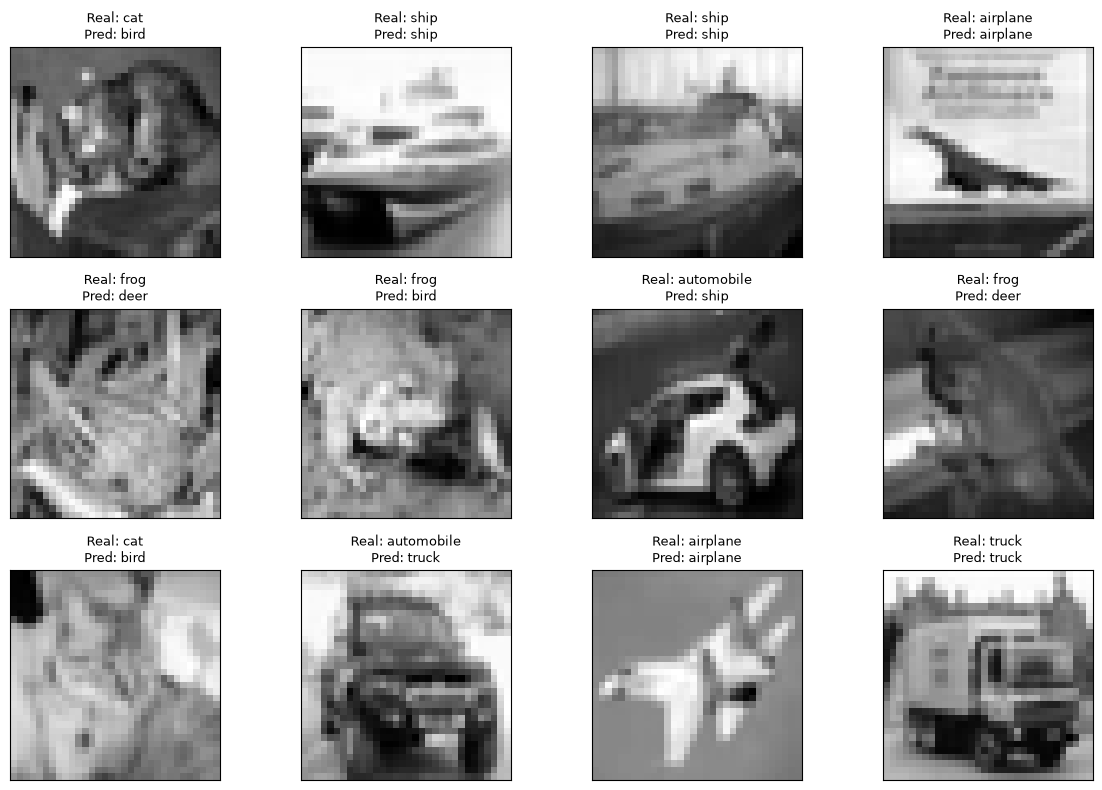

In [22]:
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:**


### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:**


### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:**


### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:**

---

## Para pensar

Nuestro modelo hace:

```text
32×32 → Flatten → 1024 valores → Dense → ReLU → Dense(10)
```

Sin embargo, una imagen tiene **estructura espacial**: existen bordes, formas y patrones locales.

Este resultado nos deja preparada la siguiente pregunta del curso:

> **¿Cómo puede una red aprovechar directamente la estructura espacial de una imagen?**

La respuesta será: **Convolutional Neural Networks (CNNs)**.
